The goal of this notebook is to build a transformer-based catch probability that builds upon the nflfastr catch probability model. This model takes that model's output as an input, and combines it with frame by frame data of both the targeted reciever and the targeted defender. We want to see how the defender's path impacts the probability of a catch. 

In [ ]:
## In order for this kaggle notebook to run properly, you must add inputs 'transformer-models' and 
##'shekher-processed-data'
## both of which are kaggle dataset inputs owned by me (can be found on my profile)

In [1]:
# install lightning
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 15.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 46.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import sys
import torch
from torch.utils.data import Dataset
import random
# Import from 'lightning' (not 'pytorch_lightning') to match models.py
from lightning import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from pathlib import Path
import lightning as L
# evaluation imports
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set all seeds
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
L.seed_everything(seed, workers=True)

# Make PyTorch deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


Here we extract the relevant features from the processed output data that Shekhar generated in a seperate R notebook.

Below, we load in the data that Shekhar preprocessed in R. His preprocessing work can be found in the preprocessing directory of our Github repo.

In [3]:
df = pd.read_csv('/kaggle/input/shekhar-processed-data/FinalOutput.csv')
# target = df[['game_id', 'play_id', 'target']]
features = df[['game_id', 'play_id', 'frame_id', 'X', 'Y', 'defenderX', 'defenderY', 'distance', 
                'distance_from_optimal', 'frechet_cumulative', 'lastrecDir', 'lastrecO', 'lastdefDir',
               'lastdefO', 'ball_land_x', 'ball_land_y', 'framesToGo', 'cp', 'man', 'target']]
df.head()

,game_id,play_id,frame_id,nfl_id,player_name.x,X,Y,player_position.x,player_name.y,defenderId,...,cp,framesToGo,pass_result,team_coverage_man_zone,target,man,lastrecDir,lastdefDir,lastrecO,lastdefO
0,2023090700,101,1,44930,Josh Reynolds,53.20,13.98,WR,Justin Reid,46137,...,0.409489,20,I,ZONE_COVERAGE,0,0,350.75,1.64,343.2,305.93
1,2023090700,101,2,44930,Josh Reynolds,53.96,13.78,WR,Justin Reid,46137,...,0.409489,19,I,ZONE_COVERAGE,0,0,350.75,1.64,343.2,305.93
2,2023090700,101,3,44930,Josh Reynolds,54.70,13.54,WR,Justin Reid,46137,...,0.409489,18,I,ZONE_COVERAGE,0,0,350.75,1.64,343.2,305.93
3,2023090700,101,4,44930,Josh Reynolds,55.41,13.27,WR,Justin Reid,46137,...,0.409489,17,I,ZONE_COVERAGE,0,0,350.75,1.64,343.2,305.93
4,2023090700,101,5,44930,Josh Reynolds,56.09,12.95,WR,Justin Reid,46137,...,0.409489,16,I,ZONE_COVERAGE,0,0,350.75,1.64,343.2,305.93


Next, I examine the percentage of passes that are caught in our dataset. 74.4% completions may sound high, but we filtered to plays where there is initially separation between the defender and receiver (at least 3 yards). This lends itself to higher rates of completion in our data.

In [4]:
df['target'].mean()

0.7441697761194029

We create train-validate-test sets.

In [5]:
plays = df[['game_id', 'play_id']].drop_duplicates()

train = plays.sample(frac=0.8, random_state=42)

remaining = plays.drop(train.index)

val = remaining.sample(frac=0.5, random_state=42)
test = remaining.drop(val.index)

In [6]:
train = train.merge(features, on=['game_id', 'play_id'], how='left')
test = test.merge(features, on=['game_id', 'play_id'], how='left')
val = val.merge(features, on=['game_id', 'play_id'], how='left')

In [7]:
train['target'].mean()

0.7446025060266497

In [8]:
test['target'].mean()

0.7407646048109966

We fit a standard scaler on the training data, then apply the scaler to all three datasets

In [9]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train.iloc[:, 3:-4])
train.iloc[:, 3:-4] = train_scaled
train

,game_id,play_id,frame_id,X,Y,defenderX,defenderY,distance,distance_from_optimal,frechet_cumulative,lastrecDir,lastrecO,lastdefDir,lastdefO,ball_land_x,ball_land_y,framesToGo,cp,man,target
0,2023111901,771,1,-0.749872,-0.753393,-0.698206,-0.743597,-0.400870,-0.916455,-0.745323,-0.690716,-1.594441,0.266100,-1.490305,-0.801940,-0.944472,9,0.781499,0,1
1,2023111901,771,2,-0.741909,-0.794089,-0.695954,-0.780508,-0.440890,-0.572463,-0.545976,-0.690716,-1.594441,0.266100,-1.490305,-0.801940,-0.944472,8,0.781499,0,1
2,2023111901,771,3,-0.735274,-0.835473,-0.694603,-0.816681,-0.474379,-0.249590,-0.350003,-0.690716,-1.594441,0.266100,-1.490305,-0.801940,-0.944472,7,0.781499,0,1
3,2023111901,771,4,-0.730408,-0.876858,-0.693702,-0.853592,-0.496671,0.072079,-0.149922,-0.690716,-1.594441,0.266100,-1.490305,-0.801940,-0.944472,6,0.781499,0,1
4,2023111901,771,5,-0.726869,-0.917554,-0.695504,-0.891979,-0.531525,0.363458,0.055486,-0.690716,-1.594441,0.266100,-1.490305,-0.801940,-0.944472,5,0.781499,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37744,2023091800,3634,3,0.344518,-1.392791,0.372899,-1.372560,-0.652079,-0.198995,-0.182604,0.919333,0.247501,1.329263,0.776700,0.252147,-1.363935,4,0.781291,0,1
37745,2023091800,3634,4,0.348942,-1.441763,0.363890,-1.430141,-0.762618,0.135293,0.087374,0.919333,0.247501,1.329263,0.776700,0.252147,-1.363935,3,0.781291,0,1
37746,2023091800,3634,5,0.353808,-1.490046,0.353981,-1.488461,-0.885807,0.463119,0.356687,0.919333,0.247501,1.329263,0.776700,0.252147,-1.363935,2,0.781291,0,1
37747,2023091800,3634,6,0.358673,-1.536259,0.343171,-1.546780,-1.020135,0.778731,0.620916,0.919333,0.247501,1.329263,0.776700,0.252147,-1.363935,1,0.781291,0,1


In [10]:
val_scaled = scaler.transform(val.iloc[:, 3:-4])
val.iloc[:, 3:-4] = val_scaled

test_scaled = scaler.transform(test.iloc[:, 3:-4])
test.iloc[:, 3:-4] = test_scaled
test.head()

,game_id,play_id,frame_id,X,Y,defenderX,defenderY,distance,distance_from_optimal,frechet_cumulative,lastrecDir,lastrecO,lastdefDir,lastdefO,ball_land_x,ball_land_y,framesToGo,cp,man,target
0,2023090700,1001,1,2.411650,0.603344,2.198462,0.146696,0.666733,-0.916455,-0.745323,-1.353421,0.17378,0.714197,-0.217686,2.20546,0.539704,11,0.626475,1,1
1,2023090700,1001,2,2.417400,0.612311,2.204317,0.143743,0.724554,-0.754409,-0.529158,-1.353421,0.17378,0.714197,-0.217686,2.20546,0.539704,10,0.626475,1,1
2,2023090700,1001,3,2.421382,0.620588,2.211074,0.145219,0.750520,-0.611926,-0.367807,-1.353421,0.17378,0.714197,-0.217686,2.20546,0.539704,9,0.626475,1,1
3,2023090700,1001,4,2.424036,0.628175,2.218280,0.150387,0.751056,-0.479722,-0.239221,-1.353421,0.17378,0.714197,-0.217686,2.20546,0.539704,8,0.626475,1,1
4,2023090700,1001,5,2.425363,0.635762,2.226388,0.159983,0.725176,-0.344574,-0.126162,-1.353421,0.17378,0.714197,-0.217686,2.20546,0.539704,7,0.626475,1,1


Here we create a PandasDataset class in order to make the data compatible with the Pytorch data architecture.

In [11]:
class PandasDataset(Dataset):
    def __init__(self, df):
        self.df = df
        # Define which columns are features (exclude IDs and target)
        self.wr = ['X', 'Y']  
        self.db = ['defenderX', 'defenderY']
        self.play = ['distance', 'man', 'distance_from_optimal', 'frechet_cumulative', 'lastrecDir',
                     'lastrecO', 'lastdefDir','lastdefO', 'cp', 'ball_land_x', 'ball_land_y',
                     'framesToGo']
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Create separate tensors for each entity
        wr = torch.tensor(row[self.wr].values, dtype=torch.float32)
        db = torch.tensor(row[self.db].values, dtype=torch.float32)
        play = torch.tensor(row[self.play].values, dtype=torch.float32)
        
        y = torch.tensor(row["target"], dtype=torch.int)
        
        # Return as tuple: (wr, db, play, target)
        return wr, db, play, y

In [12]:
train_dataset = PandasDataset(train)
val_dataset = PandasDataset(val)
test_dataset = PandasDataset(test)

In [13]:
for wr, db, play, y in train_dataset:
    print(wr.shape)
    print(db.shape)
    print(play.shape)
    print(y.shape)
    break

torch.Size([2])
torch.Size([2])
torch.Size([12])
torch.Size([])


Next we create the dataloader objects for all three datasets

In [14]:
# Create DataLoader objects
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=3)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=3)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=3)

# Print feature and target shapes from DataLoaders
for wr, db, play, y in train_loader:
    print(f"Batch WR shape: {wr.shape}")      # [64, 2]
    print(f"Batch DB shape: {db.shape}")      # [64, 2]
    print(f"Batch Play shape: {play.shape}")  # [64, 6]
    print(f"Batch Y shape: {y.shape}")        # [64]
    print(f"\nSample targets (first 10): {y[:10]}")
    break

Batch WR shape: torch.Size([256, 2])
Batch DB shape: torch.Size([256, 2])
Batch Play shape: torch.Size([256, 12])
Batch Y shape: torch.Size([256])

Sample targets (first 10): tensor([1, 0, 1, 1, 1, 1, 1, 1, 1, 0], dtype=torch.int32)


Here we define the setup for the transformer model from our completion_transformer.py file. We owe thanks to SumerSports for their helpful transformer notebook that demonstrated the use of these models on tracking data. We tailored a similar model to the task of predicting completions.

In [15]:
sys.path.append('/kaggle/input/transformer-models')
sys.path.insert(0, '/kaggle/input/transformer-models')
from completion_transformer import LitCompletionModel  # Using classification model

# Model parameters for catch probability (binary classification task)
model_type = "transformer"  # Can be "transformer" or "zoo"
batch_size = batch_size
model_dim = 64  # Dimension of transformer model (adjustable)
num_layers = 3  # Number of transformer layers (adjustable)
dropout = 0.1
learning_rate = 1e-4

# Initialize the model for binary classification (predicting pass_result)
# Output dimension is 1 (pass_result probability)
model = LitCompletionModel(
    wr_features=2,
    db_features=2,
    play_features=12,
    model_dim=64,
    num_layers=3,
    dropout=0.2,
    learning_rate=1e-3
)

print(f"Model initialized: {model_type}")
print(f"Output dimension: 1 (pass_result probability)")
print(f"Loss function: BCEWithLogitsLoss (binary classification)")
print(f"Number of parameters: {model.num_params:,}")

Model initialized: transformer
Output dimension: 1 (pass_result probability)
Loss function: BCEWithLogitsLoss (binary classification)
Number of parameters: 166,081


Below we defined the trainer and then fit it to the data.

In [16]:
# Define checkpointing to save the best model
checkpoint_callback = ModelCheckpoint(
   dirpath=Path("checkpoints/"),
   filename="best-checkpoint",
   save_top_k=1,
   verbose=True,
   monitor="val_loss",
   mode="min",
)

# Define early stopping
early_stop_callback = EarlyStopping(
   monitor="val_loss",
   min_delta=0.001,  # Minimum change in monitored value to qualify as an improvement
   patience=3,      # Number of epochs with no improvement after which training will be stopped
   verbose=True,
   mode="min"
)

# Initialize the trainer
trainer = Trainer(
    max_epochs=20,  # Adjust the number of epochs
    accelerator="gpu",  # Use 'gpu' if CUDA is available, otherwise use 'cpu'
    devices=[0],
    strategy="auto",
    callbacks=[checkpoint_callback, early_stop_callback],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [17]:
# Start training
trainer.fit(model, train_loader, val_loader)

2025-12-17 16:48:50.997932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765990131.385519      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765990131.502361      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ CompletionProbabilityModel │  166 K │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss          │      0 │ train │     0 │
└───┴─────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 166 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 166 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 57                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.513
Epoch 0, global step 148: 'val_loss' reached 0.51327 (best 0.51327), saving model to '/kaggle/working/checkpoints/best-checkpoint.ckpt' as top 1
Metric val_loss improved by 0.008 >= min_delta = 0.001. New best score: 0.505
Epoch 1, global step 296: 'val_loss' reached 0.50521 (best 0.50521), saving model to '/kaggle/working/checkpoints/best-checkpoint.ckpt' as top 1
Epoch 2, global step 444: 'val_loss' was not in top 1
Metric val_loss improved by 0.006 >= min_delta = 0.001. New best score: 0.500
Epoch 3, global step 592: 'val_loss' reached 0.49970 (best 0.49970), saving model to '/kaggle/working/checkpoints/best-checkpoint.ckpt' as top 1
Epoch 4, global step 740: 'val_loss' was not in top 1
Epoch 5, global step 888: 'val_loss' was not in top 1
Monitored metric val_loss did not improve in the last 3 records. Best score: 0.500. Signaling Trainer to stop.
Epoch 6, global step 1036: 'val_loss' was not in top 1


In [18]:
# Inference on test data - get catch predictions
predictions = trainer.predict(model, test_loader)
print(f"Generated predictions for {len(test_loader.dataset)} test samples")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

Generated predictions for 4656 test samples


### In all that follows, we conduct model evaluation.

In [19]:
# Concatenate predictions into a single tensor
predictions_tensor = torch.cat(predictions, dim=0)

# Predictions are probabilities (0-1) for man v. zone
print(f"Predictions shape: {predictions_tensor.shape}")
print(f"Sample predictions (first 10):")
print(predictions_tensor[:10])
print(f"\nPrediction range: [{predictions_tensor.min():.3f}, {predictions_tensor.max():.3f}]")

# Convert to binary predictions (threshold at 0.5)
binary_predictions = (predictions_tensor > 0.5).float()
print(f"\nBinary predictions (first 10): {binary_predictions[:10].int().tolist()}")

Predictions shape: torch.Size([4656])
Sample predictions (first 10):
tensor([0.7372, 0.7710, 0.8042, 0.8317, 0.8536, 0.8631, 0.8710, 0.8766, 0.8784,
        0.8798])

Prediction range: [0.073, 0.910]

Binary predictions (first 10): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [20]:
# Extract catch labels from the test_loader
y_true = torch.cat([target for wr, db, play, target in test_loader], dim=0)

# Convert tensors to numpy arrays
y_true_np = y_true.cpu().numpy()
predicted_probs_np = predictions_tensor.cpu().numpy()
predicted_binary_np = binary_predictions.cpu().numpy()

print("Ground truth shape:", y_true_np.shape)
print("Predicted probabilities shape:", predicted_probs_np.shape)
print("Predicted binary shape:", predicted_binary_np.shape)

print(f"\nSample ground truth labels (first 10):")
print(y_true_np[:10].astype(int))
print(f"\nSample predicted probabilities (first 10):")
print(predicted_probs_np[:10])
print(f"\nSample predicted binary labels (first 10):")
print(predicted_binary_np[:10].astype(int))

Ground truth shape: (4656,)
Predicted probabilities shape: (4656,)
Predicted binary shape: (4656,)

Sample ground truth labels (first 10):
[1 1 1 1 1 1 1 1 1 1]

Sample predicted probabilities (first 10):
[0.73715687 0.7709763  0.80422044 0.83173764 0.8535801  0.8631249
 0.87102985 0.87662995 0.8783915  0.8797585 ]

Sample predicted binary labels (first 10):
[1 1 1 1 1 1 1 1 1 1]


In [21]:
df_test_all = test_dataset.df.copy()
df_test_all['pass_result_pred'] = predicted_binary_np.astype(int)
df_test_all['pass_result_true'] = y_true_np
df_test_all['pass_result_prob'] = predicted_probs_np

print("=" * 80)
print("DATA STRUCTURE ANALYSIS")
print("=" * 80)
print(f"Total test samples (all frames): {len(df_test_all):,}")
print(f"Unique plays: {df_test_all.groupby(['game_id', 'play_id']).ngroups:,}")
print(f"Average frames per play: {len(df_test_all) / df_test_all.groupby(['game_id', 'play_id']).ngroups:.1f}")

# CLASS DISTRIBUTION
print("\n" + "=" * 80)
print("CLASS DISTRIBUTION")
print("=" * 80)

print(f"\nGround Truth Distribution:")
print(df_test_all['pass_result_true'].value_counts().sort_index())
print(f"  pass_result=1: {df_test_all['pass_result_true'].sum():,} ({100*df_test_all['pass_result_true'].mean():.1f}%)")
print(f"  pass_result=0: {(~df_test_all['pass_result_true'].astype(bool)).sum():,} ({100*(1-df_test_all['pass_result_true'].mean()):.1f}%)")

print(f"\nPredicted Distribution:")
print(df_test_all['pass_result_pred'].value_counts().sort_index())
print(f"  pass_result=1: {df_test_all['pass_result_pred'].sum():,} ({100*df_test_all['pass_result_pred'].mean():.1f}%)")
print(f"  pass_result=0: {(~df_test_all['pass_result_pred'].astype(bool)).sum():,} ({100*(1-df_test_all['pass_result_pred'].mean()):.1f}%)")

# FILTER TO LAST FRAME PER PLAY
print("\n" + "=" * 80)
print("FILTERING TO LAST FRAME PER PLAY")
print("=" * 80)

# Get the last frame_id for each unique (gameId, playId) pair
df_test = df_test_all .loc[df_test_all.groupby(['game_id', 'play_id'])['frame_id'].idxmax()].reset_index(drop=True)

print(f"✓ Filtered from {len(df_test_all):,} frames to {len(df_test):,} plays (last frame only)")
print(f"✓ This represents {len(df_test):,} unique plays")

# Calculate metrics
df_test['correct'] = (df_test['pass_result_pred'] == df_test['pass_result_true']).astype(int)

print("\n" + "=" * 80)
print("Test predictions dataframe (LAST FRAME PER PLAY):")
print("=" * 80)
display(df_test.head(5))

DATA STRUCTURE ANALYSIS
Total test samples (all frames): 4,656
Unique plays: 447
Average frames per play: 10.4

CLASS DISTRIBUTION

Ground Truth Distribution:
pass_result_true
0    1207
1    3449
Name: count, dtype: int64
  pass_result=1: 3,449 (74.1%)
  pass_result=0: 1,207 (25.9%)

Predicted Distribution:
pass_result_pred
0     778
1    3878
Name: count, dtype: int64
  pass_result=1: 3,878 (83.3%)
  pass_result=0: 778 (16.7%)

FILTERING TO LAST FRAME PER PLAY
✓ Filtered from 4,656 frames to 447 plays (last frame only)
✓ This represents 447 unique plays

Test predictions dataframe (LAST FRAME PER PLAY):


,game_id,play_id,frame_id,X,Y,defenderX,defenderY,distance,distance_from_optimal,frechet_cumulative,...,ball_land_x,ball_land_y,framesToGo,cp,man,target,pass_result_pred,pass_result_true,pass_result_prob,correct
0,2023090700,1001,12,2.405457,0.688183,2.286294,0.289172,0.217641,0.542978,0.434551,...,2.205460,0.539704,0,0.626475,1,1,1,1,0.883460,1
1,2023090700,1741,7,2.083421,-0.435419,1.975502,-1.052173,0.895947,1.655326,3.338018,...,1.863224,-0.293138,0,0.438748,1,1,1,1,0.905038,1
2,2023091001,2151,8,1.146510,-0.454042,1.200325,-0.265231,-0.300553,0.323760,0.111873,...,1.055974,-0.389453,0,0.778069,0,1,1,1,0.899404,1
3,2023091001,4662,9,-0.842767,0.791646,-0.579745,0.777135,1.327050,1.515558,1.373308,...,-0.890066,0.736741,0,0.694300,0,1,1,1,0.902181,1
4,2023091002,4036,18,0.065833,-1.425209,-0.045994,-1.553424,-1.830044,0.960776,1.677788,...,0.022849,-1.268250,0,0.364192,0,0,0,0,0.178796,1


In [22]:
df_test_all.to_csv('/kaggle/working/preds.csv', index=False)

In [23]:
# Extract values for easier access
true_labels = df_test['pass_result_true'].values
pred_labels = df_test['pass_result_pred'].values
pred_probs = df_test['pass_result_prob'].values
correct = df_test['correct'].values

CATCH PREDICTION - CLASSIFICATION METRICS
(Evaluated on LAST FRAME of each play only)

📊 Evaluation Dataset:
  Number of plays evaluated: 447
  (Filtered from 4,656 total frames)

📈 Classification Metrics:
  Accuracy:   0.8031 (80.31%)
  Precision:  0.8406
  Recall:     0.9263
  F1-Score:   0.8814
  ROC AUC:    0.7054

📊 Confusion Matrix:
                Predicted
              0       1
  Actual 0     32     62
         1     26    327


Detailed Classification Report:
              precision    recall  f1-score   support

       CATCH       0.55      0.34      0.42        94
  INCOMPLETE       0.84      0.93      0.88       353

    accuracy                           0.80       447
   macro avg       0.70      0.63      0.65       447
weighted avg       0.78      0.80      0.78       447



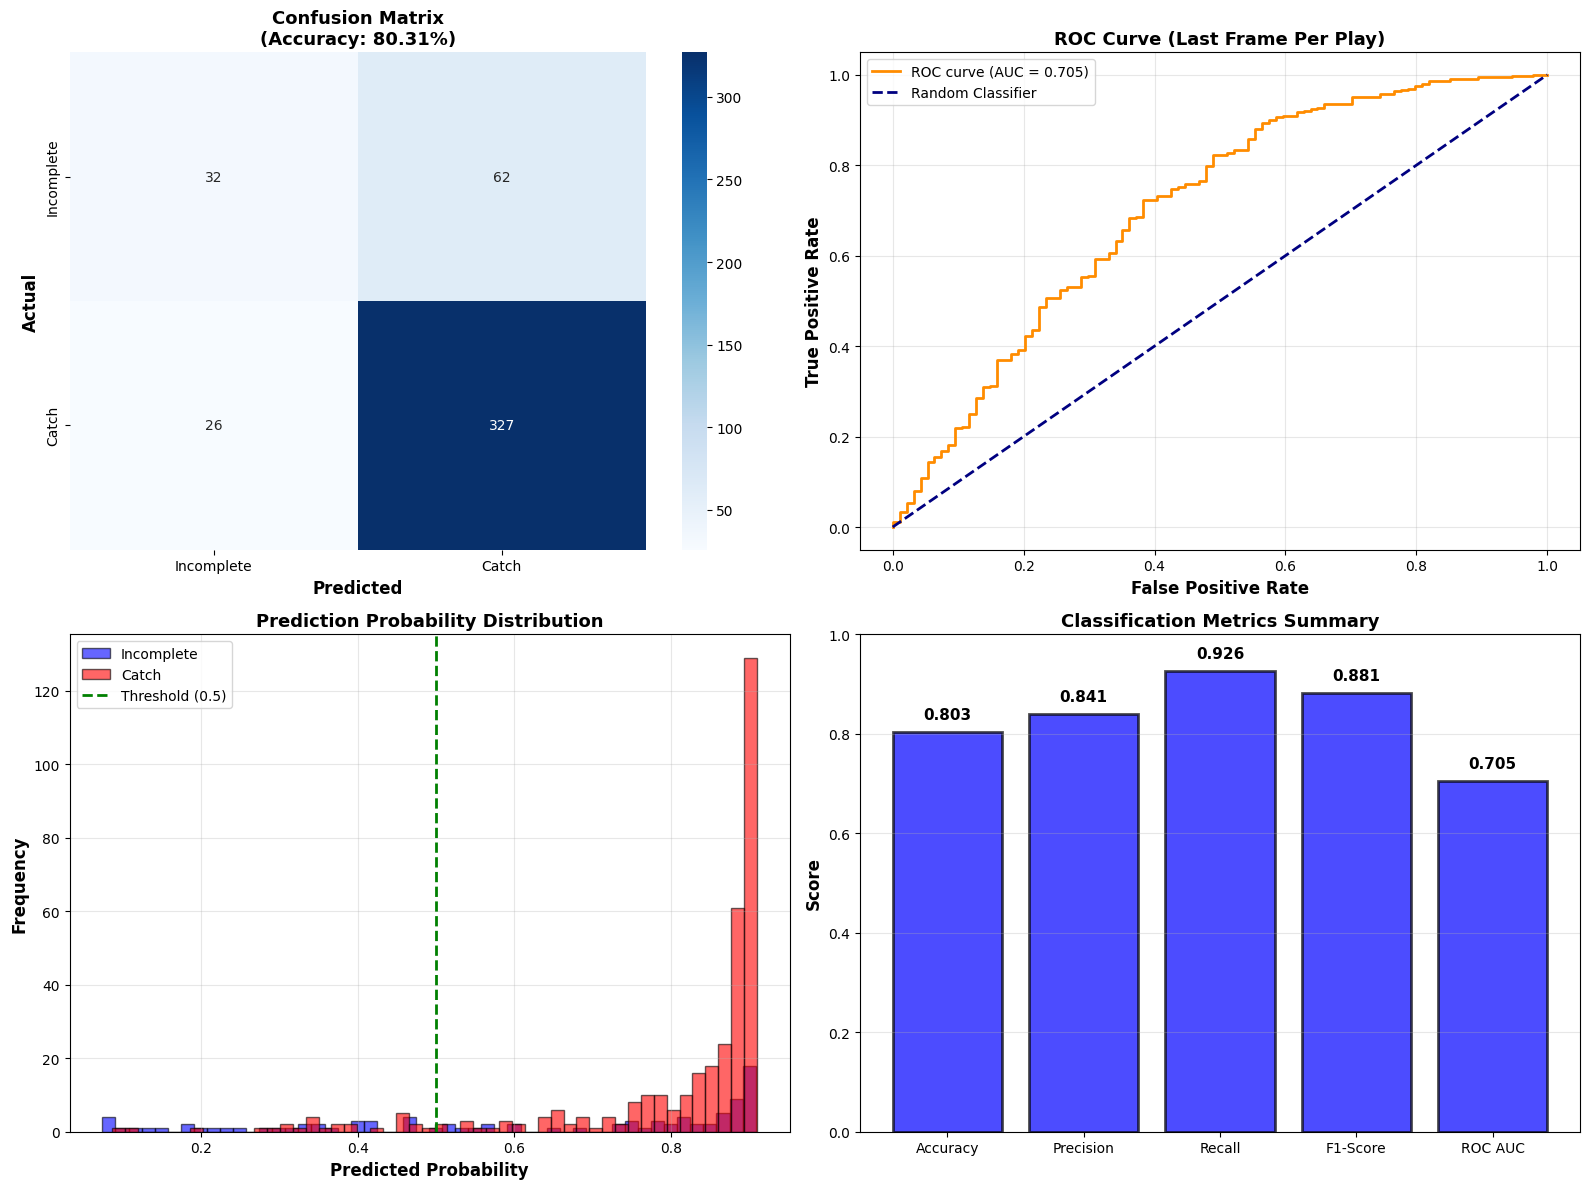

In [24]:
# Calculate classification metrics (using LAST FRAME PER PLAY only)
accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, zero_division=0)
recall = recall_score(true_labels, pred_labels, zero_division=0)
f1 = f1_score(true_labels, pred_labels, zero_division=0)
cm = confusion_matrix(true_labels, pred_labels)

# ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

# Print metrics
print("=" * 80)
print("CATCH PREDICTION - CLASSIFICATION METRICS")
print("(Evaluated on LAST FRAME of each play only)")
print("=" * 80)

print(f"\n📊 Evaluation Dataset:")
print(f"  Number of plays evaluated: {len(df_test):,}")
print(f"  (Filtered from {len(df_test_all):,} total frames)")

print("\n📈 Classification Metrics:")
print(f"  Accuracy:   {accuracy:.4f} ({100*accuracy:.2f}%)")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  F1-Score:   {f1:.4f}")
print(f"  ROC AUC:    {roc_auc:.4f}")

print("\n📊 Confusion Matrix:")
print(f"                Predicted")
print(f"              0       1")
print(f"  Actual 0   {cm[0][0]:4d}   {cm[0][1]:4d}")
print(f"         1   {cm[1][0]:4d}   {cm[1][1]:4d}")

print("\n" + "=" * 80)
print("\nDetailed Classification Report:")
print("=" * 80)
print(classification_report(true_labels, pred_labels, target_names=['CATCH', 'INCOMPLETE']))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
           xticklabels=['Incomplete', 'Catch'], yticklabels=['Incomplete', 'Catch'])
axes[0, 0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0, 0].set_title(f'Confusion Matrix\n(Accuracy: {accuracy:.2%})', 
                    fontsize=13, fontweight='bold')

# ROC Curve
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0, 1].set_title('ROC Curve (Last Frame Per Play)', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Prediction Probability Distribution
axes[1, 0].hist(pred_probs[true_labels == 0], bins=50, alpha=0.6, label='Incomplete', color='blue', edgecolor='black')
axes[1, 0].hist(pred_probs[true_labels == 1], bins=50, alpha=0.6, label='Catch', color='red', edgecolor='black')
axes[1, 0].axvline(0.5, color='green', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1, 0].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bar chart of metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors = ['blue' if v >= 0.7 else 'orange' if v >= 0.5 else 'red' for v in metrics_values]

bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Classification Metrics Summary', fontsize=13, fontweight='bold')
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{value:.3f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# Save the dataframe
df_test.to_csv('/kaggle/working/test_set_data.csv', index=False)

print("File saved! To download:")
print("1. Click the arrow on the right side panel (>>)")
print("2. Click 'Output' tab")
print("3. Find 'test_set_data.csv' and click download icon")

File saved! To download:
1. Click the arrow on the right side panel (>>)
2. Click 'Output' tab
3. Find 'test_set_data.csv' and click download icon


In [26]:
# Extract values for easier access
df_test['correct'] = (df_test['cp'].round() == df_test['pass_result_true']).astype(int)
true_labels = df_test['pass_result_true'].values
pred_labels = df_test['cp'].round().values
pred_probs = df_test['cp'].values
correct = df_test['correct'].values
df_test['correct'].mean()

0.7874720357941835

CATCH PREDICTION - CLASSIFICATION METRICS
(Evaluated on LAST FRAME of each play only)

📊 Evaluation Dataset:
  Number of plays evaluated: 447
  (Filtered from 4,656 total frames)

📈 Classification Metrics:
  Accuracy:   0.7875 (78.75%)
  Precision:  0.8308
  Recall:     0.9178
  F1-Score:   0.8721
  ROC AUC:    0.6602

📊 Confusion Matrix:
                Predicted
              0       1
  Actual 0     28     66
         1     29    324


Detailed Classification Report:
              precision    recall  f1-score   support

       CATCH       0.49      0.30      0.37        94
  INCOMPLETE       0.83      0.92      0.87       353

    accuracy                           0.79       447
   macro avg       0.66      0.61      0.62       447
weighted avg       0.76      0.79      0.77       447



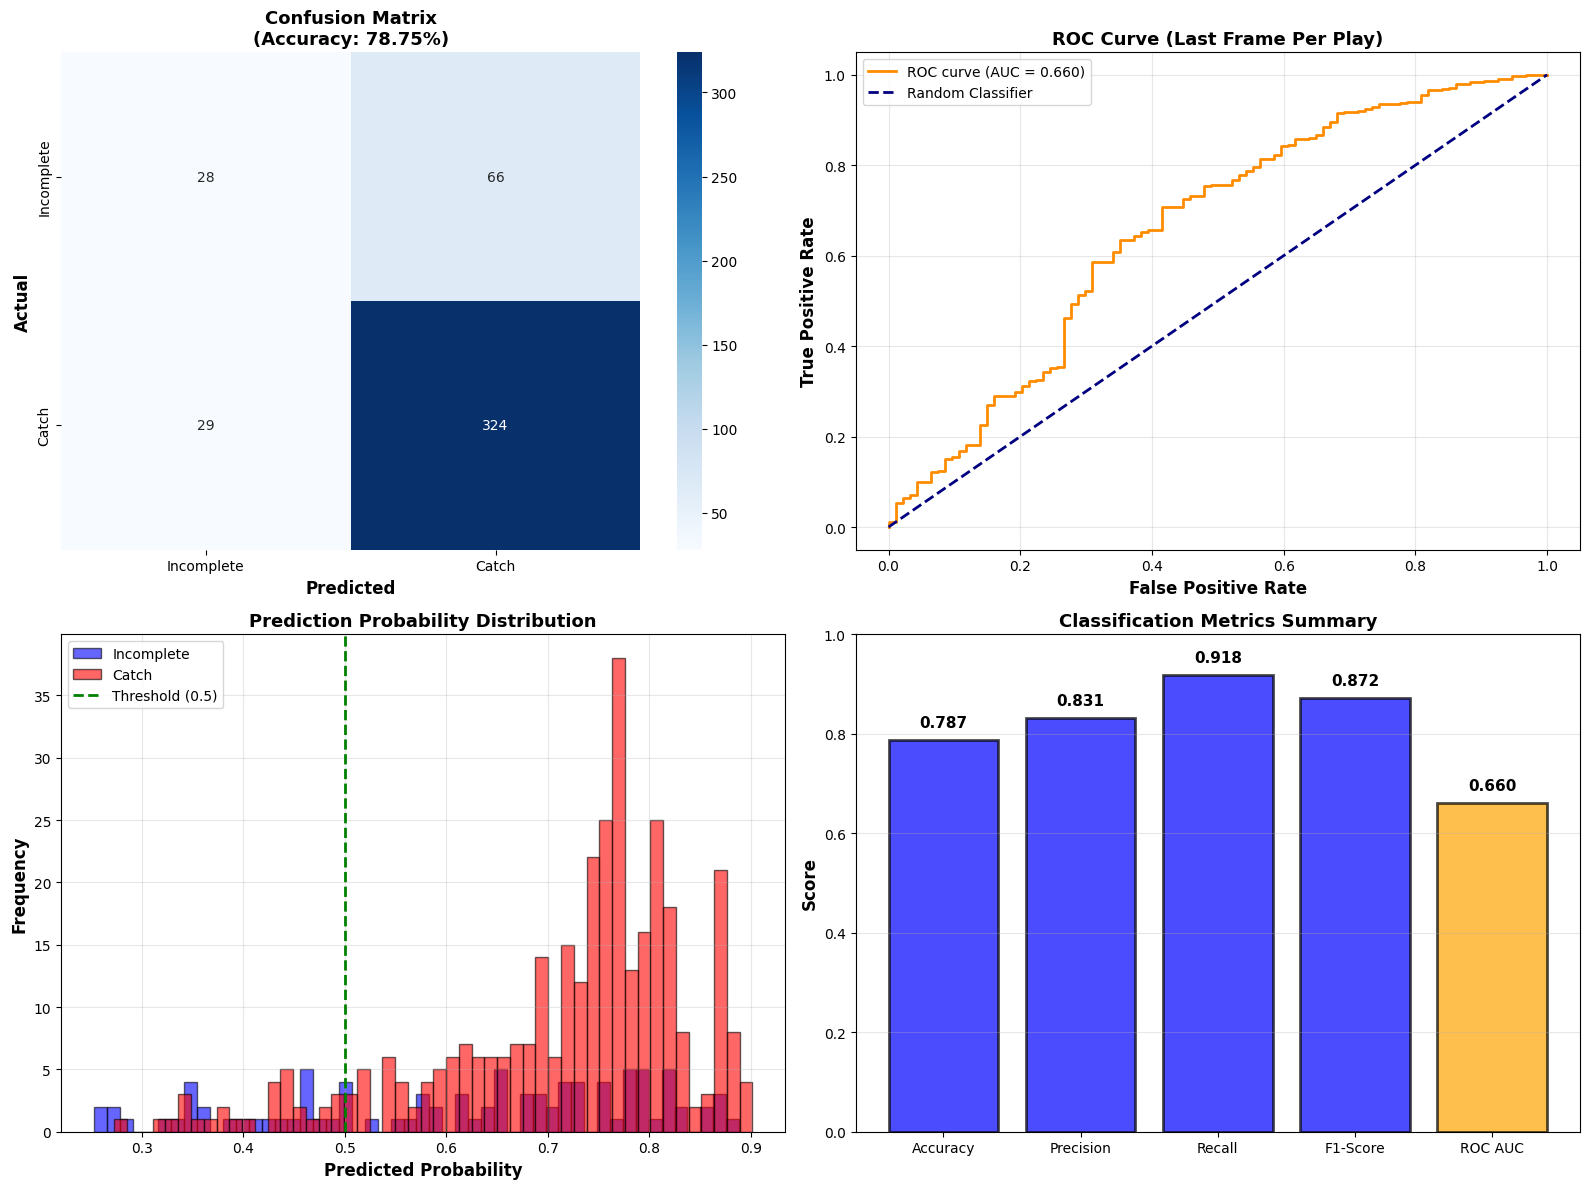

In [27]:
# Calculate classification metrics (using LAST FRAME PER PLAY only)
accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, zero_division=0)
recall = recall_score(true_labels, pred_labels, zero_division=0)
f1 = f1_score(true_labels, pred_labels, zero_division=0)
cm = confusion_matrix(true_labels, pred_labels)

# ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

# Print metrics
print("=" * 80)
print("CATCH PREDICTION - CLASSIFICATION METRICS")
print("(Evaluated on LAST FRAME of each play only)")
print("=" * 80)

print(f"\n📊 Evaluation Dataset:")
print(f"  Number of plays evaluated: {len(df_test):,}")
print(f"  (Filtered from {len(df_test_all):,} total frames)")

print("\n📈 Classification Metrics:")
print(f"  Accuracy:   {accuracy:.4f} ({100*accuracy:.2f}%)")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  F1-Score:   {f1:.4f}")
print(f"  ROC AUC:    {roc_auc:.4f}")

print("\n📊 Confusion Matrix:")
print(f"                Predicted")
print(f"              0       1")
print(f"  Actual 0   {cm[0][0]:4d}   {cm[0][1]:4d}")
print(f"         1   {cm[1][0]:4d}   {cm[1][1]:4d}")

print("\n" + "=" * 80)
print("\nDetailed Classification Report:")
print("=" * 80)
print(classification_report(true_labels, pred_labels, target_names=['CATCH', 'INCOMPLETE']))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
           xticklabels=['Incomplete', 'Catch'], yticklabels=['Incomplete', 'Catch'])
axes[0, 0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0, 0].set_title(f'Confusion Matrix\n(Accuracy: {accuracy:.2%})', 
                    fontsize=13, fontweight='bold')

# ROC Curve
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0, 1].set_title('ROC Curve (Last Frame Per Play)', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Prediction Probability Distribution
axes[1, 0].hist(pred_probs[true_labels == 0], bins=50, alpha=0.6, label='Incomplete', color='blue', edgecolor='black')
axes[1, 0].hist(pred_probs[true_labels == 1], bins=50, alpha=0.6, label='Catch', color='red', edgecolor='black')
axes[1, 0].axvline(0.5, color='green', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1, 0].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bar chart of metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors = ['blue' if v >= 0.7 else 'orange' if v >= 0.5 else 'red' for v in metrics_values]

bars = axes[1, 1].bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Classification Metrics Summary', fontsize=13, fontweight='bold')
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{value:.3f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
sl_features = df[['game_id', 'play_id', 'frame_id', 'X', 'Y', 'straight_line_x', 'straight_line_y',
                  'distance', 'distance_from_optimal', 'frechet_cumulative', 'lastrecDir', 'lastrecO', 
                  'lastdefDir', 'lastdefO', 'ball_land_x', 'ball_land_y', 'framesToGo', 'cp', 'man', 
                  'target']]
sl_features = sl_features.rename(columns={'straight_line_x':'defenderX', 'straight_line_y':'defenderY'})
sl_features['distance_from_optimal'] = 0
sl_features['frechet_cumulative'] = 0
sl_features['distance'] = np.sqrt((sl_features['X'] - sl_features['defenderX'])**2 + (sl_features['Y'] - sl_features['defenderY'])**2)
sl_features.head()

,game_id,play_id,frame_id,X,Y,defenderX,defenderY,distance,distance_from_optimal,frechet_cumulative,lastrecDir,lastrecO,lastdefDir,lastdefO,ball_land_x,ball_land_y,framesToGo,cp,man,target
0,2023090700,101,1,53.20,13.98,56.220000,17.280000,4.473299,0,0,350.75,343.2,1.64,305.93,63.259998,-0.22,20,0.409489,0,0
1,2023090700,101,2,53.96,13.78,56.433779,16.748588,3.864208,0,0,350.75,343.2,1.64,305.93,63.259998,-0.22,19,0.409489,0,0
2,2023090700,101,3,54.70,13.54,56.658114,16.190938,3.295707,0,0,350.75,343.2,1.64,305.93,63.259998,-0.22,18,0.409489,0,0
3,2023090700,101,4,55.41,13.27,56.885134,15.626613,2.780224,0,0,350.75,343.2,1.64,305.93,63.259998,-0.22,17,0.409489,0,0
4,2023090700,101,5,56.09,12.95,57.120142,15.042430,2.332264,0,0,350.75,343.2,1.64,305.93,63.259998,-0.22,16,0.409489,0,0


In [29]:
sl_scaled = scaler.transform(sl_features.iloc[:, 3:-4])
sl_features.iloc[:, 3:-4] = sl_scaled
sl_features.head()

/tmp/ipykernel_47/3999458059.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.91645512 -0.91645512 -0.91645512 ... -0.91645512 -0.91645512
 -0.91645512]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sl_features.iloc[:, 3:-4] = sl_scaled
/tmp/ipykernel_47/3999458059.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.74532309 -0.74532309 -0.74532309 ... -0.74532309 -0.74532309
 -0.74532309]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sl_features.iloc[:, 3:-4] = sl_scaled


,game_id,play_id,frame_id,X,Y,defenderX,defenderY,distance,distance_from_optimal,frechet_cumulative,lastrecDir,lastrecO,lastdefDir,lastdefO,ball_land_x,ball_land_y,framesToGo,cp,man,target
0,2023090700,101,1,-0.441992,-0.845130,-0.444168,-0.660917,-0.382167,-0.916455,-0.745323,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,20,0.409489,0,0
1,2023090700,101,2,-0.408373,-0.858925,-0.434539,-0.700147,-0.606230,-0.916455,-0.745323,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,19,0.409489,0,0
2,2023090700,101,3,-0.375638,-0.875479,-0.424434,-0.741313,-0.815361,-0.916455,-0.745323,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,18,0.409489,0,0
3,2023090700,101,4,-0.344231,-0.894102,-0.414209,-0.782973,-1.004989,-0.916455,-0.745323,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,17,0.409489,0,0
4,2023090700,101,5,-0.314151,-0.916174,-0.403623,-0.826098,-1.169778,-0.916455,-0.745323,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,16,0.409489,0,0


In [30]:
sl_dataset = PandasDataset(sl_features)

In [31]:
sl_loader = DataLoader(sl_dataset, batch_size=batch_size, shuffle=False, num_workers=3)

In [32]:
# Inference on straight line data - get catch predictions
predictions = trainer.predict(model, sl_loader)
print(f"Generated predictions for {len(sl_loader.dataset)} test samples")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

Generated predictions for 47168 test samples


In [33]:
# Concatenate predictions into a single tensor
predictions_tensor = torch.cat(predictions, dim=0)

# Predictions are probabilities (0-1) for man v. zone
print(f"Predictions shape: {predictions_tensor.shape}")
print(f"Sample predictions (first 10):")
print(predictions_tensor[:10])
print(f"\nPrediction range: [{predictions_tensor.min():.3f}, {predictions_tensor.max():.3f}]")

# Convert to binary predictions (threshold at 0.5)
binary_predictions = (predictions_tensor > 0.5).float()
print(f"\nBinary predictions (first 10): {binary_predictions[:10].int().tolist()}")

Predictions shape: torch.Size([47168])
Sample predictions (first 10):
tensor([0.0855, 0.0808, 0.0788, 0.0786, 0.0788, 0.0789, 0.0788, 0.0786, 0.0786,
        0.0789])

Prediction range: [0.072, 0.907]

Binary predictions (first 10): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [34]:
# Extract catch labels from the test_loader
y_true = torch.cat([target for wr, db, play, target in sl_loader], dim=0)

# Convert tensors to numpy arrays
y_true_np = y_true.cpu().numpy()
predicted_probs_np = predictions_tensor.cpu().numpy()
predicted_binary_np = binary_predictions.cpu().numpy()

print("Ground truth shape:", y_true_np.shape)
print("Predicted probabilities shape:", predicted_probs_np.shape)
print("Predicted binary shape:", predicted_binary_np.shape)

print(f"\nSample ground truth labels (first 10):")
print(y_true_np[:10].astype(int))
print(f"\nSample predicted probabilities (first 10):")
print(predicted_probs_np[:10])
print(f"\nSample predicted binary labels (first 10):")
print(predicted_binary_np[:10].astype(int))

Ground truth shape: (47168,)
Predicted probabilities shape: (47168,)
Predicted binary shape: (47168,)

Sample ground truth labels (first 10):
[0 0 0 0 0 0 0 0 0 0]

Sample predicted probabilities (first 10):
[0.08550822 0.08080741 0.07879703 0.07855497 0.07879438 0.07886772
 0.07875936 0.07863656 0.07863454 0.07889843]

Sample predicted binary labels (first 10):
[0 0 0 0 0 0 0 0 0 0]


In [35]:
df_sl_all = sl_dataset.df.copy()
df_sl_all['pass_result_pred'] = predicted_binary_np.astype(int)
df_sl_all['pass_result_true'] = y_true_np
df_sl_all['pass_result_prob'] = predicted_probs_np

In [36]:
df_sl_all.to_csv('/kaggle/working/sl_preds_data.csv', index=False)

Fit the model on the original dataset

In [37]:
og = features.copy()
og_scaled = scaler.transform(og.iloc[:, 3:-4])
og.iloc[:, 3:-4] = og_scaled
og.head()

,game_id,play_id,frame_id,X,Y,defenderX,defenderY,distance,distance_from_optimal,frechet_cumulative,lastrecDir,lastrecO,lastdefDir,lastdefO,ball_land_x,ball_land_y,framesToGo,cp,man,target
0,2023090700,101,1,-0.441992,-0.845130,-0.444168,-0.660917,-0.382167,-0.916455,-0.745323,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,20,0.409489,0,0
1,2023090700,101,2,-0.408373,-0.858925,-0.425701,-0.690445,-0.522683,-0.733954,-0.581748,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,19,0.409489,0,0
2,2023090700,101,3,-0.375638,-0.875479,-0.406332,-0.721451,-0.646600,-0.542706,-0.410404,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,18,0.409489,0,0
3,2023090700,101,4,-0.344231,-0.894102,-0.387415,-0.753932,-0.761543,-0.365323,-0.255517,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,17,0.409489,0,0
4,2023090700,101,5,-0.314151,-0.916174,-0.368046,-0.787890,-0.857226,-0.186692,-0.100762,1.629284,1.608643,-1.672018,1.185125,-0.034048,-1.664841,16,0.409489,0,0


In [38]:
og_dataset = PandasDataset(og)

In [39]:
og_loader = DataLoader(og_dataset, batch_size=batch_size, shuffle=False, num_workers=3)

In [40]:
# Inference on straight line data - get catch predictions
predictions = trainer.predict(model, og_loader)
print(f"Generated predictions for {len(og_loader.dataset)} test samples")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

Generated predictions for 47168 test samples


In [41]:
# Concatenate predictions into a single tensor
predictions_tensor = torch.cat(predictions, dim=0)

# Predictions are probabilities (0-1) for man v. zone
print(f"Predictions shape: {predictions_tensor.shape}")
print(f"Sample predictions (first 10):")
print(predictions_tensor[:10])
print(f"\nPrediction range: [{predictions_tensor.min():.3f}, {predictions_tensor.max():.3f}]")

# Convert to binary predictions (threshold at 0.5)
binary_predictions = (predictions_tensor > 0.5).float()
print(f"\nBinary predictions (first 10): {binary_predictions[:10].int().tolist()}")

Predictions shape: torch.Size([47168])
Sample predictions (first 10):
tensor([0.0855, 0.0829, 0.0821, 0.0829, 0.0856, 0.0901, 0.0960, 0.1040, 0.1138,
        0.1247])

Prediction range: [0.072, 0.917]

Binary predictions (first 10): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [42]:
# Extract catch labels from the test_loader
y_true = torch.cat([target for wr, db, play, target in sl_loader], dim=0)

# Convert tensors to numpy arrays
y_true_np = y_true.cpu().numpy()
predicted_probs_np = predictions_tensor.cpu().numpy()
predicted_binary_np = binary_predictions.cpu().numpy()

print("Ground truth shape:", y_true_np.shape)
print("Predicted probabilities shape:", predicted_probs_np.shape)
print("Predicted binary shape:", predicted_binary_np.shape)

print(f"\nSample ground truth labels (first 10):")
print(y_true_np[:10].astype(int))
print(f"\nSample predicted probabilities (first 10):")
print(predicted_probs_np[:10])
print(f"\nSample predicted binary labels (first 10):")
print(predicted_binary_np[:10].astype(int))

Ground truth shape: (47168,)
Predicted probabilities shape: (47168,)
Predicted binary shape: (47168,)

Sample ground truth labels (first 10):
[0 0 0 0 0 0 0 0 0 0]

Sample predicted probabilities (first 10):
[0.08550822 0.0828874  0.08207174 0.08292551 0.08558235 0.09006689
 0.09604206 0.10402078 0.11380845 0.12465664]

Sample predicted binary labels (first 10):
[0 0 0 0 0 0 0 0 0 0]


In [43]:
df_og_all = og_dataset.df.copy()
df_og_all['pass_result_pred'] = predicted_binary_np.astype(int)
df_og_all['pass_result_true'] = y_true_np
df_og_all['pass_result_prob'] = predicted_probs_np

In [44]:
df_og_all.to_csv('/kaggle/working/og_preds_data.csv', index=False)

In [47]:
df_og_all['correct'] = (df_og_all['pass_result_pred'] == df_og_all['pass_result_true']).astype(int)

# Get the indices of the final frame for each play
final_frame_indices = df_og_all.groupby(['game_id', 'play_id'])['frame_id'].idxmax()

# Use .loc to select those rows and calculate accuracy
df_og_all.loc[final_frame_indices, 'correct'].mean()

0.8240554437737536